In [31]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]=T[1] # Left boundary
    T[-1]=T[-2]**2/max(T[-3],1e-40) # Right boundary

def solve_two_layer_FTCS(k1, k2, z_dis,Pda,Lz,nz,tf,device):
    # Construct numerical grid
    dz = Lz/nz; z = torch.arange(-0.5, nz+1, device=device)*dz
    # Finite volume, *** z_dis is at a cell boundary ***
    # need one more point at each end, *** size of z = (nz+2) ***

    # Make sure we reach tf in integer number of setps
    dt = 0.5*(dz**2)/max(k1, k2) # need to include k1 and k2 in dt
    nt = int(np.ceil(tf/dt)); dt = tf/nt # need to uopdate dt 
    print(f'nz = {nz}, nt = {nt}; alignment of nt*dt with tf: err = {nt*dt-tf}')
    
    # Find index m such that z[m+1] > z_dis
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    # no need to move a scalar between gpu and cpu?
    # check z[m+1/2]=z_dis?
    print(f'alignment of cell boundary with z_dis: err = {z[m]+0.5*dz-z_dis}')
    
    # Harmonic mean of k at z_dis
    k_interface = 2 * k1 * k2 / (k1 + k2)
    # Precompute kh (effective k at half grid point z_{j+1/2})
    kh = torch.where(z[:-1] < z_dis, k1, k2); kh[m] = k_interface
    # *** size of kh = (nz+1) ***
    # Pytorch will automatically use the device and dtype of z
    
    # Source at internal points, *** size of source = nz ***
    source = Pda * torch.exp(-z[1:-1])

    # Need to pre-allocate T and J
    T = torch.zeros(nz+2, device=device) # size of T = nz+2
    Jh = torch.zeros(nz+1, device=device) # size of k = nz+1
    
    # advance in time steps
    for tstep in range(nt):
        # FTCS update
        set_BCs(T) # start each step by enforcing BCs
        Jh = -kh * (T[1:]-T[:-1])/dz # Flux 
        T[1:-1] = T[1:-1] + dt/dz*(Jh[:-1] - Jh[1:])+dt*source
    set_BCs(T) # at the end enforce BC again
    
    # Map T to Th (T at half grid points z_{j+1/2}); This mapping is nevessary 
    # because coarse grid and fine grid do not share any common cell centers!!!
    zh = 0.5*(z[:-1]+z[1:])
    Th = 0.5*(T[:-1]+T[1:]); Th[m]=T[m]+0.5*(T[m+1]-T[m])*k_interface/k1
    return z, T, zh, Th

In [52]:
import numpy as np
import torch

def solver_wrapper(params):
    """
    params: numpy array [k1, k2]
    returns: scalar output from the solver
    """

    # Unpack GP parameters
    k1, k2 = params

    # Fixed solver settings
    z_dis = 2.5     # example — change to your value
    Pda   = 1.0     # example
    Lz    = 5.0     # example
    nz    = 100     # example
    tf    = 2     # example
    device = 'cuda'

    # --- Call your real solver (in same notebook) ---
    z, T, zh, Th= solve_two_layer_FTCS(k1, k2, z_dis, Pda, Lz, nz, tf, device)

    # ---- Extract a scalar to emulate ----
    # Example: temperature at mid-layer at final time
    scalar_output = Th.cpu()

    return scalar_output


In [53]:
def generate_training_data(Ntrain):
    X = []
    y = []

    for _ in range(Ntrain):
        k1 = 1
        k2 = 2

        params = np.array([k1, k2])
        X.append(params)
        y.append(solver_wrapper(params))

    return np.array(X), np.array(y)


In [54]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

kernel = RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8,optimizer=None)

# Generate data
Xtrain, ytrain = generate_training_data(40)

gp.fit(Xtrain, ytrain)
print("GP trained.")


nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignme

In [56]:
k1_test = 1
k2_test = 2



params_test = np.array([k1_test, k2_test])

mean_pred, std_pred = gp.predict(params_test.reshape(1, -1), return_std=True)

print("GP Mean:", mean_pred[0])
print("GP Std:", std_pred[0])


nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
nz = 100, nt = 3200; alignme

ValueError: x has 2 columns but y has 101 columns

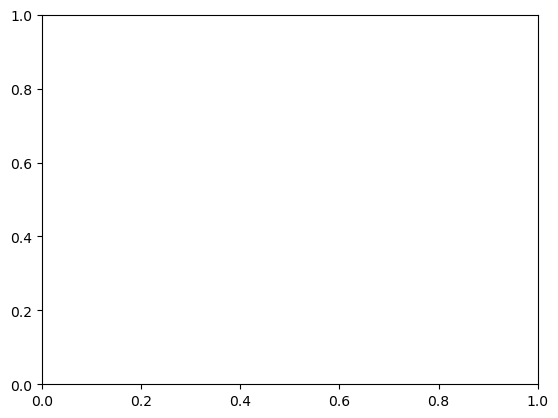

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(X_star, f(X_star), 'k--', label="True f(x)")
plt.scatter(X, y, c='r', s=30, label="Observed (f(x)+noise)")
plt.plot(X_star, y_mean, 'b', label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 y_mean - 2*y_std,
                 y_mean + 2*y_std,
                 color='b', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(-0.6,6.6); plt.ylim(-2.8,2.8)
plt.title("Test 1: GP Regression using a package")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(True)
plt.text(0.1, 0.1, ' data: 25 observed values of f(x)+noise ', \
        transform=plt.gca().transAxes, fontsize=12, color='red',ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.show()